# Example of usage for **y_call** package: making Y-haplogroup calls #

***

## Description ## 

This Jupter Notebook contains an explained and guided usage of **y_call**, a software designed to make Y-haplogroup calls both on modern and aDNA data. Here, absolute paths in the local clsuter have been considered for input data, but these can be specified by the user at any other location.

***

## Installation ##

Import modules:

In [1]:
# Import modules
import numpy as np
import os  # for saving to folder
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcdefaults() # default settings to avoid warnings related to font.
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

import os as os
import sys as sys

from liftover import get_lifter # to convert positions from hg38 to hg19 (used to align reads).
import re # to work with regular expressions.
import pathlib
from pathlib import Path

Import package:

In [2]:
sys.path.append("..")

# Import package from current directory.
from pulldown import y_call

# Change working directory to location of Jupyter Notebook.
notebook_path = os.path.abspath("")
os.chdir(notebook_path)

In [3]:
os.getcwd()

'/mnt/archgen/users/eric_garcia/Jupyter_Vignette'

***

## Understanding necessary input files ##

This section contains a brief explanation on the input files necessary to run the package. Other arguments provided to it stand for filtering options, as well as the creation of a network connecting haplogroups and samples. 

**NOTE**: the first five files are required by the package. The last four of these can be passed only by providing the name of the directory (or database) where these are found (YFull for this vignette, as it is the default value in the package). The program looks for: *<./data/input/{database}/>* 

**<span style="color:blue">Additional files</span>**: the last two files are not required but can serve to have additional information for Y-haplogroups.

> **bam_list**: relative or abosulte (preferibly) path to a .tsv file containing a list of the routes to different .bam files. This file contains 3 columns in total:
> 1. **iid**: the ID for every sample.
> 2. **bam**: absolute path to each .bam file.
> 3. **sex**: chromosomal sex for every sample. f = female, m = mascle.

In [4]:
bam_list = "/home/eric_garcia_hoyos/y_call/example.tsv"

# Show the content of the file
table1 = pd.read_csv(bam_list, sep="\t", usecols=["iid", "bam", "sex"])
table1.head()

,iid,bam,sex
0,PTN271,/mnt/archgen/Autorun_eager/eager_outputs/SG/PT...,f
1,PTN225,/mnt/archgen/Autorun_eager/eager_outputs/SG/PT...,f
2,PTN209,/mnt/archgen/Autorun_eager/eager_outputs/SG/PT...,m
3,PTN287,/mnt/archgen/Autorun_eager/eager_outputs/SG/PT...,f
4,PTN557,/mnt/archgen/Autorun_eager/eager_outputs/SG/PT...,m


> **path_snps**: relative or abosulte (preferibly) path to a .csv file containing a list of the SNPs considered in the analysis. This file contains 4 columns in total:
> 1. **Coordinates**: genome coordinates in chrY (hg38 version in the example).
> 2. **ANC**: ancestral allele.
> 3. **DER**: derived allele.
> 4. **SNP-ID**: name of the SNP at that location.

In [5]:
# Specify name of the source database
database = "YFull"

In [6]:
path_snps = f"/home/eric_garcia_hoyos/y_call/data/input/{database}/snps.csv"

# Show the content of the file
table2 = pd.read_csv(path_snps, dtype=object, sep=" ", header=None, names = ["Coordinates", "ANC", "DER", "SNP-ID"])
table2

,Coordinates,ANC,DER,SNP-ID
0,8936213,T,C,BY32772
1,377858,T,C,YFS068754
2,410030,A,T,Z993
3,445364,A,C,BY2892
4,636930,G,A,FGC56146
...,...,...,...,...
3146951,16849922,C,T,A32907_CP086569.1
3146952,62004810,T,C,A30994_CP086569.1
3146953,8180296,A,G,A30883_CP086569.1
3146954,12246698,T,A,A32899_CP086569.1


> **tree**: relative or abosulte (preferibly) path to a .csv file containing child - parent pairs of haplogroups. Although not named in original file, there exist 2 columns:
> 1. **Child**: every haplogroup as a descendant of another haplogroup.
> 2. **Parent**: parental node of the **Child** haplogroup.
> 
> **NOTE**: This file corresponds to the Y-haplogroup tree where samples are placed.

In [7]:
tree = f"/home/eric_garcia_hoyos/y_call/data/input/{database}/tree.csv"

# Show the content of the file
table3 = pd.read_csv(tree, header=None, names = ["Child", "Parent"])
table3

,Child,Parent
0,A00,NaN
1,A00*,A00
2,A00-Y125399,A00
3,A00-Y125399*,A00-Y125399
4,A00c,A00-Y125399
...,...,...
67527,O-Y154488*,O-Y154488
67528,O-MF2,O-Y154488
67529,O-MF2*,O-MF2
67530,O-FGC29526,O-MF2


In [8]:
# If Child selected for a specific haplogroup (R1b):
table3[table3["Child"]=="R1b"]

,Child,Parent
47892,R1b,R1


In [9]:
# If Parent selected for a specific haplogroup (R1b):
table3[table3["Parent"]=="R1b"]

,Child,Parent
47893,R1b*,R1b
47894,R-L754,R1b
62065,R-PH491,R1b


> **mm**: relative or abosulte (preferibly) path to a .tsv file containing the number of samples where a SNP had an ancestral allele. Although not named in the original file, there exist 2 columns:
> 1. **SNP-ID**: name of the SNP.
> 2. **count**: total number of samples with the ancestral allele.
> 
> **NOTE**: this file can also be created by executing the script *create_mm.py*, after making a first Y-haplogroup call.

In [10]:
mm = f"/home/eric_garcia_hoyos/y_call/data/input/{database}/mm.tsv"

# Show the content of the file
table5 = pd.read_csv(mm, sep="\t")
table5.head()

,SNP-ID,count
0,FGC26539,130
1,PF794,117
2,FGC26816,117
3,PF964,113
4,FGC24743,112


> **branches**: relative or abosulte (preferibly) path to a .csv file containing the name of each haplogroup (first value) and all SNPs contained inside that haplogroup (rest of values).

In [11]:
branches = f"/home/eric_garcia_hoyos/y_call/data/input/{database}/haps.csv"

# Show the content of the file
with open(branches, "r") as f:
    for line in f.readlines()[10:11]: # read a single line of the document.
        items = line.strip().split() # because every line is: X-XXXX X123 X542 XG56*
        print(f"\nThis is the content of a whole line in the file: {items}")
        if not items:
            continue

        hap = items[0] # only the first value (the haplogroup).
        snps = items[1:] # the rest of values (the SNPs).
        print(f"\n--> Where the haplogroup is: {hap}\n\n--> And the set of SNPs contained inside of it is: {snps}")


This is the content of a whole line in the file: ['A-L1035', 'L1040', 'L1049', 'L1042', 'L1048', 'L1046', 'L1038', 'L1050', 'L1056', 'L1041', 'L1057', 'L1039', 'L1052', 'L1045', 'L1051', 'L1054', 'L1036', 'L1047', 'L1037', 'L1058', 'M7785', 'ZS588', 'S6189', 'ZS608', 'PF659', 'M10377', 'ZS1224', 'MF671643', 'L1035', 'L1044', 'L1043']

--> Where the haplogroup is: A-L1035

--> And the set of SNPs contained inside of it is: ['L1040', 'L1049', 'L1042', 'L1048', 'L1046', 'L1038', 'L1050', 'L1056', 'L1041', 'L1057', 'L1039', 'L1052', 'L1045', 'L1051', 'L1054', 'L1036', 'L1047', 'L1037', 'L1058', 'M7785', 'ZS588', 'S6189', 'ZS608', 'PF659', 'M10377', 'ZS1224', 'MF671643', 'L1035', 'L1044', 'L1043']


######

**<span style="color:blue">Additional files</span>**

> **translation**: relative or abosulte (preferibly) path to a .csv file containing synonymous names for Y-haplogroups to avoid inconsistencies between databases. Although not named in the original file, there exist 2 columns:
> 1. **Large**: nomenclature based on the alphabetical order (ISOGG standard), usually referred as large nomeclature (since names become larger). 
> 2. **Short**: SNP-based nomenclature, where every haplogroup is named after the defining SNP of the branch.

In [12]:
translation = "/home/eric_garcia_hoyos/y_call/data/input/YF-translations.csv"

# Show the content of the file
table4 = pd.read_csv(translation, header=None, names = ["Large", "Short"])[20:30]
table4

,Large,Short
20,A3b2b,A-M118
21,B,B-M60
22,B1,B-M146
23,B2a,B-M150
24,B2a1,B-M109
25,B2a2,B-M108.1
26,B2a2a,B-M43
27,B2b,B-M112
28,B2b1,B-P6
29,B2b2,B-M115


> **ages**: relative or abosulte (preferibly) path to a .csv file containing age estimates for every Y-haplogroup contained in the reference tree. This file contains 7 columns in total:
> 1. **Y-haplogroup**: name of the Y-haplogroup.
> 2. **Formed**: years before present when the Y-haplogroup was originated.
> 3. **Formed_low**: lower formed estimate under a 95% CI.
> 4. **Formed_high**: higher formed estimate under a 95% CI.
> 5. **TMRCA**: years before present until reaching the Most Recent Common Ancestor (MRCA).
> 6. **TMRCA_low**: lower TMRCA estimate under a 95% CI.
> 7. **TMRCA_high**: higher TMRCA estimate under a 95% CI.

In [13]:
ages = "/home/eric_garcia_hoyos/y_call/data/input/ages.csv"

table6 = pd.read_csv(ages)
table6

,Y-haplogroup,Formed,Formed_low,Formed_high,TMRCA,TMRCA_low,TMRCA_high
0,A00,235900,228300,243700,37600,33100,42200
1,A00*,37600,33100,42200,37600,33100,42200
2,A00-Y125399,37600,33100,42200,37600,33100,42200
3,A00-Y125399*,0,0,0,0,0,0
4,A00c,0,0,0,0,0,0
...,...,...,...,...,...,...,...
67527,O-Y154488*,2000,1250,2800,2000,1250,2800
67528,O-MF2,2000,1250,2800,2000,1250,2800
67529,O-MF2*,2000,1250,2800,2000,1250,2800
67530,O-FGC29526,2000,1250,2800,1850,1200,2700


***

## Running **y_call** on a single sample ##

So, now that we have all our necessary input files loaded, we can run the program. To do so, we provide a few more parameters so that the analysis considers some aspects:
> **initial**: index for first the sample to analyse.
> 
> **final**: index for the last sample to analyse.
>
> **base_qual**: minimum base quality considered for the call.
>
> **map_qual**: minimum mapping quality for the call.
>
> **reference_genome**: version of the human genome used for the markers' coordinates.
>
> **create_phylogeny**: desired tree connecting haplogroups and placing samples in it. Y = Yes, N = No.
>
> **width**: width size for the network.
>
> **height**: height size for the network.
>
> **transitions**: filtering for transitions. Y = Yes, N = No.
>
> **ex_limit**: minimum number of samples supporting an ancestral allele for one of the SNPs in mm.

In [16]:
# Run function for the software: y_call.
y_call(bam_list=bam_list, initial=2, final=3,
       base_qual=20, map_qual=25, database=database, 
       reference_genome="hg38", create_phylogeny="N", 
       width=120, height=90, transitions="Y", 
       translation=translation, ex_limit=5, ages=ages)


## Process input data ##
--------------------
Dataset for filtered markers missing
Creating file...
Loaded 3146956 SNPs
# Out of range positions in hg19: 45
# Positions available: 3093518
# Biallelic SNPs: 3085615
# Ref & Alt different: 3085488
# Ref & Alt ACTG: 3085287
# Unique SNP positions: 2909406
Loading haplogroups information...
Done
Saved as ./data/output/all_snps_YFull.csv
Coresponding .bed file in ./data/output/YFull_snps.bed

## Load individuals ##
--------------------
Loaded a total of 1 male individuals.

## Summary coverage statistics for sample KKH019 ##
--------------------
Average Coverage: 0.2935x
Sites covered: 671468 / 2925037
Derived Loci: 2949 / 671468 covered>0

## Process output files for sample KKH019 ##
--------------------
Saved data for pileup as data/output/markers/KKH019/snps_KKH019.tsv
Saved data for pileup (considering only derived sites) as data/output/markers/KKH019/snps_der_KKH019.tsv
Saved data for Y-haplgroup calls as data/output/haplogroups/KKH019

***

## Understanding the output ##

This section contains a brief explanation on the output files generated by the package. All this information is stored in an automatically created directory, found in ./data/output

> **./data/output/markers/iid/snps_iid.tsv**: this file contains information only for those SNPs covered in the analysis. This file contains a total of 14 columns:
> 1. **SNP-ID**: name of the SNP.
> 2. **chrom**: chromosome where the SNP is located.
> 3. **pos**: genomic coordinates for the SNP.
> 4. **ref**: refference allele.
> 5. **alt**: alternative allele.
> 6. **Y-haplogroup**: name of the Y-haplogroup.
> 7. **Level**: number of steps from Root until current node.
> 8. **[ACGT]**: number of reads supporting each base.
> 9. **ref#**: number of reads supporting the refference allele.
> 10. **alt#**: number of reads supporting the alternative allele.

In [19]:
data1 = pd.read_csv("data/output/markers/KKH019/snps_KKH019.tsv", sep="\t")
data1

,SNP-ID,chrom,pos,ref,alt,Y-haplogroup,YFull translation,Level,A,C,G,T,ref#,alt#
0,Y562367,Y,2649888,A,G,NaN,NaN,0,1,0,0,0,1,0
1,FTB49845,Y,2649897,C,G,NaN,NaN,0,0,1,0,0,1,0
2,Y654946,Y,2649898,T,A,NaN,NaN,0,0,0,0,1,1,0
3,MF121600,Y,2649899,A,G,NaN,NaN,0,1,0,0,0,1,0
4,MY103,Y,2649911,C,G,NaN,NaN,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503448,BY227657,Y,59033110,A,T,NaN,NaN,0,1,0,0,0,1,0
503449,TY34949,Y,59033135,A,T,NaN,NaN,0,1,0,0,0,1,0
503450,BY227607,Y,59033139,T,C,NaN,NaN,0,0,0,0,1,1,0
503451,Y553748,Y,59033175,T,A,NaN,NaN,0,0,0,0,1,1,0


> **./data/output/markers/iid/snps_der_iid.tsv**: this file follows the same structure as the previous, with the only difference that it contains information only for SNPs considered as derived (alternative allele count higher than ancestral count).  

In [20]:
data2 = pd.read_csv("data/output/markers/KKH019/snps_der_KKH019.tsv", sep="\t")
data2

,SNP-ID,chrom,pos,ref,alt,Y-haplogroup,YFull translation,Level,A,C,G,T,ref#,alt#
0,A10970,Y,13687378,A,T,NaN,NaN,0,0,0,0,9,0,9
1,A11362,Y,9816634,C,T,R-A11360,NaN,51,0,0,0,1,0,1
2,A12214,Y,3713460,G,A,NaN,NaN,0,1,0,0,0,0,1
3,A13510,Y,9771941,T,A,NaN,NaN,0,1,0,0,0,0,1
4,A13792,Y,13486797,G,C,NaN,NaN,0,0,3,1,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2944,ZS5231,Y,16297466,G,A,J-ZS5226,NaN,43,1,0,0,0,0,1
2945,ZS6558,Y,21828241,G,A,NaN,NaN,0,1,0,0,0,0,1
2946,ZS7939,Y,13450812,A,G,NaN,NaN,0,1,0,4,0,1,4
2947,ZS8026,Y,15202045,T,C,NaN,NaN,0,0,1,0,0,0,1


> **./data/output/trees/iid/tree_output_iid.txt**: this file contains information for the whole path until the most derived Y-haplogroup assigned to an individual. Every line is divided as follows:
> 1. **[Haplogroup Name]**: first item in line indicating the name of the Y-haplogroup.
> 2. **Level**: number of steps from Root until current node.
> 3. **DER in branch**: number of SNPs with derived state in current node (marked in grey the total of SNPs for the node).
> 4. **ANC in branch**: number of SNPs with ancestral state in current node (marked in grey the total of SNPs for the node).
> 5. **DER in par.**: number of SNPs with derived state from Root until current node (marked in gray the total of SNPs for parent nodes).
> 6. **ANC in par.**: number of SNPs with ancestral state from Root until current node (marked in gray the total of SNPs for parent nodes).

**NOTE**: if no SNPs for a Y-haplogroup have been covered, the total count is considered 0 and it is labeled as "Not Found". 

In [21]:
with open ("data/output/trees/KKH019/tree_output_KKH019.txt", "r") as file:
    for line in file.readlines():
        print(line,end="")

Tree created for sample KKH019, with most derived Y-haplogroup: I-Y19207
|
|___> Y-Chromosome Adam, Level: 0, DER in branch: 0, Not Found, ANC in branch: 0, Not Found, DER in par.: 0, Not Found, ANC in par.: 0, Not Found
  |
  |___> A0-T, Level: 1, DER in branch: 116/117, ANC in branch: 1/117, DER in par.: 0/0, ANC in par.: 0/0
    |
    |___> A1, Level: 2, DER in branch: 35/35, ANC in branch: 0/35, DER in par.: 116/117, ANC in par.: 1/117
      |
      |___> A1b, Level: 3, DER in branch: 14/14, ANC in branch: 0/14, DER in par.: 151/152, ANC in par.: 1/152
        |
        |___> BT, Level: 4, DER in branch: 70/70, ANC in branch: 0/70, DER in par.: 165/166, ANC in par.: 1/166
          |
          |___> CT, Level: 5, DER in branch: 52/52, ANC in branch: 0/52, DER in par.: 235/236, ANC in par.: 1/236
            |
            |___> CF, Level: 6, DER in branch: 0, Not Found, ANC in branch: 0, Not Found, DER in par.: 0, Not Found, ANC in par.: 0, Not Found
              |
              |_

> **./data/output/haplogroups/iid/haplogroup_iid.tsv**: this file contains information supporting each of the Y-haplogroups considered in the analysis. The last row in this table corresponds to the Y-haplogroup assigned to the sample, as it has the highest score. There are a total of 14 different columns:
> 1. **Branch**: name of the Y-haplogroup.
> 2. **Level**: number of steps from Root until current node.
> 3. **Total_SNPs**: number of covered SNPs for the Y-haplogroup.
> 4. **Ancestral**: number of SNPs with ancestral states.
> 5. **Derived**: number of SNPs with derived states.
> 6. **Uncovered**: number of SNPs other than derived or ancestral.
> 7. **#ANC in par.**: number of SNPs with ancestral states in upstream nodes until Root.
> 8. **#DER in par.**: number of SNPs with derived states in upstream nodes until Root.
> 9. **#UNC IN PAR.**: number of SNPs other than derived or ancestral in upstream nodes until Root.
> 10. **Total in par.**: total number of covered SNPs in upstream nodes until Root.
> 11. **Derived/Total**: proportion of derived SNPs and the Total number of SNPs in a Y-haplogroup.
> 12. **#ANC in par./#DER in par.**: ratio between ancestral and derived SNPs i upstream nodes until Root.
> 13. **Support**: number of upstream nodes where Derived/Total proportion is above 0.95.
> 14. **Score**: value obtained from the following calculus:
$$
S = \#\text{DER in par.} + \text{Derived} - 3\left(\#\text{ANC in par.} + \text{Ancestral}\right)
$$

In [22]:
data4 = pd.read_csv("data/output/haplogroups/KKH019/haplogroup_KKH019.tsv",sep="\t")
data4

,Y-haplogroup,Level,Total_SNPs,Ancestral,Derived,Uncovered,#ANC in par.,#DER in par.,#UNC in par.,Total in par.,Derived/Total,#ANC in par./#DER in par.,Support,Score
0,NaN,0,432759,431614,1145,0,0,0,0,0,0.002646,NaN,0.0,-1293697
1,A00b,3,2,2,0,0,464,19,0,483,0.000000,24.421053,0.0,-1379
2,A00-Y125399,2,61,59,2,0,405,17,0,422,0.032787,23.823529,0.0,-1373
3,A00,1,422,405,17,0,0,0,0,0,0.040284,NaN,0.0,-1198
4,A-V1280,5,25,25,0,0,281,116,0,397,0.000000,2.422414,1.0,-802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22965,I-Y5486,29,2,0,2,0,2,385,0,387,1.000000,0.005195,13.0,381
22966,I-Y5474,30,1,0,1,0,2,387,0,389,1.000000,0.005168,14.0,382
22967,I-Y33114,34,1,1,0,0,2,391,0,393,0.000000,0.005115,17.0,382
22968,I-Y5483,31,1,0,1,0,2,388,0,390,1.000000,0.005155,15.0,383


> **./data/output/paths.txt**: this file contains similar information to the tree created above, with the difference that every line is made by the sample ID and the Y-haplogroup names sorted from Root until most derived haplogroup.

In [23]:
with open ("data/output/paths.txt", "r") as file:
    for line in file.readlines():
        print(line,end="")

KKH019: Y-Chromosome Adam,A0-T,A1,A1b,BT,CT,CF,F,GHIJK,HIJK,IJK,IJ,I,I1,I-L121,I-DF29,I-Z2893,I-Y2592,I-Z2336,I-Z2337,I-S6346,I-L22,I-Y3549,I-Y485709,I-CTS6868,I-Z74,I-L813,I-Y515276,I-Y5476,I-Y5486,I-Y5474,I-Y5483,I-Y19207


> **./data/output/scores.csv**: this is the file containing information for the most derived Y-haplogroup assigned to every sample considered in the study. Although not named in original file, there exist 5 columns:
> 1. **Sample-ID**: name for the sample analysed.
> 2. **Y-haplogroup**: name of the Y-haplogroup assigned to the sample.
> 3. **Level**: number of steps from Root until current node.
> 4. **#ANC in par./#DER in par.**: ratio between the number of ancestral SNPs and derived SNPs in parent nodes of the Y-haplogroup assigned.
> 5. **Score**: value obtained for the calculation of the pre-defined score.

In [24]:
data3 = pd.read_csv("data/output/scores.csv", header=None, names = ["Sample-ID", "Y-haplogroup", "Level", "#ANC in par./#DER in par.", "Score"])
data3

,Sample-ID,Y-haplogroup,Level,#ANC in par./#DER in par.,Score
0,KKH019,I-Y19207,32,0.005141,385


> **./data/output/hap_ages.csv**: this file contains information for age estimates according to the most derived haplogroup assigned to every sample. Although not named in original file, there exits 4 columns:
> 1. **Sample-ID**: name for the sample analysed.
> 2. **Y-haplogroup**: name of the Y-haplogroup assigned to the sample.
> 3. **Formed**: years before present when the Y-haplogroup was originated.
> 4. **TMRCA**: years before present until reaching the Most Recent Common Ancestor (MRCA).

In [25]:
data4 = pd.read_csv("data/output/hap_ages.csv", header=None, names = ["Sample-ID", "Y-haplogroup", "Formed", "TMRCA"])
data4

,Sample-ID,Y-haplogroup,Formed,TMRCA
0,KKH019,I-Y19207,1850,1550


***

## Running **y_call** on the whole set of samples ##


## Process input data ##
--------------------
Dataset for filtered markers already saved: ./data/output/all_snps_YFull.csv
Corresponding .bed file in data/output/YFull_snps.bed

## Load individuals ##
--------------------
Loaded a total of 4 male individuals.

## Summary coverage statistics for sample PTN209 ##
--------------------
Average Coverage: 7.3176x
Sites covered: 2402780 / 2925037
Derived Loci: 6834 / 2402780 covered>0

## Process output files for sample PTN209 ##
--------------------
Saved data for pileup as data/output/markers/PTN209/snps_PTN209.tsv
Saved data for pileup (considering only derived sites) as data/output/markers/PTN209/snps_der_PTN209.tsv
Saved data for Y-haplgroup calls as data/output/haplogroups/PTN209/haplogroup_PTN209.tsv
Y-haplogroup simplified tree saved as data/output/trees/PTN209/tree_output_PTN209.txt

## Update global output files ##
--------------------
Path to most derived haplogroup included in data/output/paths.txt

## Summary coverage statistics

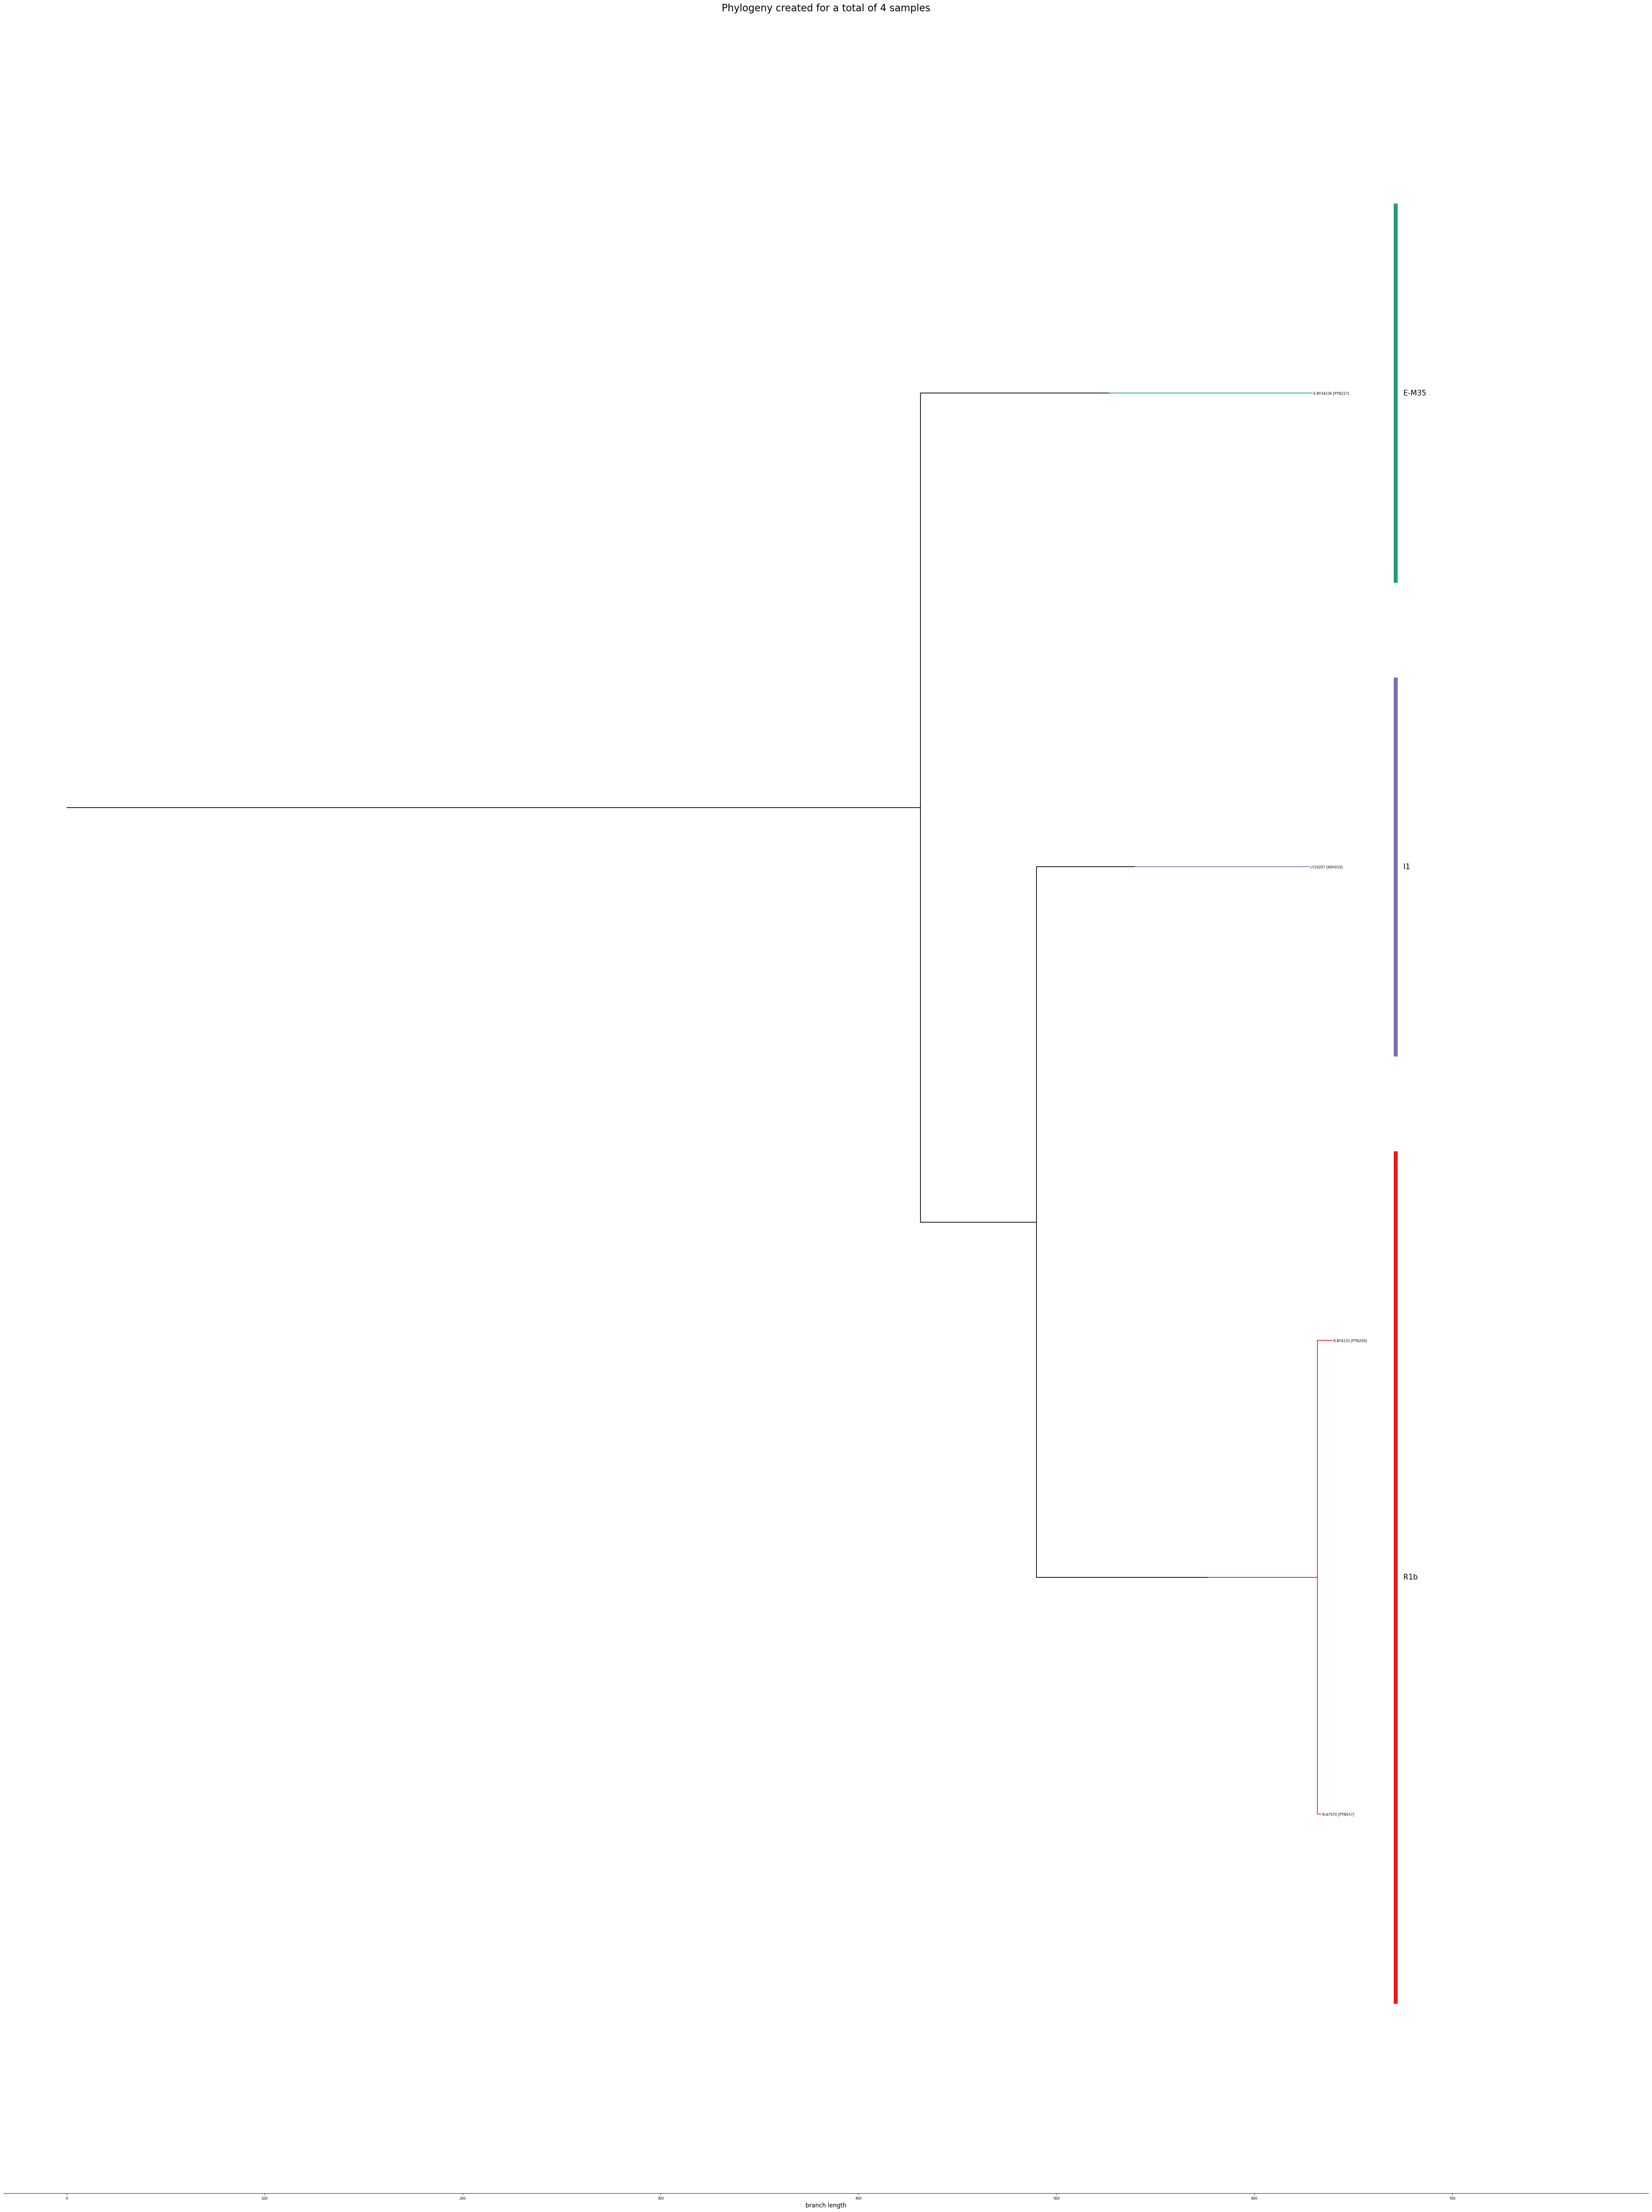

In [26]:
# Run function for the software: y_call.
y_call(bam_list=bam_list, initial=0, final=0,
       base_qual=20, map_qual=25, database=database, 
       reference_genome="hg38", create_phylogeny="Y", 
       width=60, height=80, transitions="Y", 
       translation=translation, ex_limit=5, ages=ages)